# 🐍 Python Level 1 - Introductory course
## Class 4 — Mini-Project — Department Budget Review
### 📝 Mini-Project

**Python instructor - Fábio Moreira and Luis Dias**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">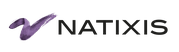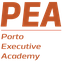</div>

---

---

## What you will build

The finance team sends round a file of what every department **planned** to spend each month
and what it **actually** spent. Somebody has to turn that into a short review: who is on
budget, who is over, and by how much. Today that somebody is you.

By the end of the session you will have a notebook that reads the raw file, cleans it, works
out the figures, prints a readable report with a status per department, and saves a summary
file the team could open in Excel.

This is the first thing you have built that someone else could actually use and it needs
everything from the three classes so far, not just pandas.

```
   expenses.csv
        │
        ▼
   load and look           parts 1-2    pandas
   clean it
        │
        ▼
   difference, over_budget  part 3      pandas
        │
        ▼
   totals per department    part 4      groupby
        │
        ▼
   a dict of departments    part 5      data structures
        │
        ▼
   report with a status     part 6      loops and conditions
        │
        ▼
   department_review.csv    part 7      export
```

> 🕐 You have the full session. Work down the outlined parts in order. **Each part leaves you with
> something that runs**, so if you only reach part 5 you still have a working program.

---

---
## The data

The same `expenses.csv` you used in Class 3. Put it in your Google Colab files space before you start.

| Column | Holds |
|--------|-------|
| `department` | which department spent the money |
| `category` | what it was spent on — Travel, Software, Training, Office, Consulting |
| `month` | `2026-01` … `2026-06` |
| `budget` | what was planned, in EUR |
| `actual` | what was actually spent, in EUR |
| `notes` | always empty — it is there to be dropped |

One row looks like this:

```
   department  category    month  budget    actual  notes
0  Operations    Travel  2026-01    7500   7307.02    NaN
```

**The file is not clean.** It has duplicated rows, some blank `actual` values, and the same
department written in more than one way. Part 2 deals with all of that and it matters, because
every number after part 2 depends on it.

---

---
## Requirements

Your finished notebook must use all of these. Each one traces back to a class.

| # | Requirement | From class |
|---|-------------|-----------|
| 1 | Load a CSV and inspect it — `.shape`, `.columns`, `.head()`, `.nunique()` | 3 |
| 2 | Clean it — duplicates, missing values, messy text, an unwanted column | 3 |
| 3 | Create new columns, including a `True`/`False` one | 3 |
| 4 | Filter rows with a condition | 3 |
| 5 | Summarise with `groupby` | 3 |
| 6 | Build a **dictionary** holding one entry per department, and a **set** | 2 |
| 7 | Loop over that dictionary and apply rules with `if` / `elif` / `else` | 1 |
| 8 | Count things with `+=` | 1 |
| 9 | Print a lined-up report using **f-strings** with format specifiers | 1 |
| 10 | Export a summary to CSV | 3 |

---

## ⚙️ Setup

Run this first.

In [ ]:
import pandas as pd

# Put expenses.csv in your Google Colab folder space first, then run this cell and allow access.
CSV_PATH = "expenses.csv"

---
## Part 1 — Load the file and look at it

Read the CSV into a variable called `expenses`, then print: its shape, its column names as a
list, how many different **departments** it thinks there are, how many different **months**,
and the first 3 rows.

Expected output:
```
Rows and columns: (154, 6)
Columns         : ['department', 'category', 'month', 'budget', 'actual', 'notes']
Departments     : 12
Months          : 6

   department  category    month  budget    actual  notes
0  Operations    Travel  2026-01    7500   7307.02    NaN
1  Operations  Software  2026-01    9500  10552.53    NaN
2  Operations  Training  2026-01   17000  20052.32    NaN
```

> 💡 **Twelve departments?** There are only five. Do not fix it here. Just notice it, and
> keep it in mind for part 2. Finding something odd in the first five minutes is what looking
> at your data is for.

In [ ]:
# Part 1

---
## Part 2 — Clean it

Make a cleaned copy called `clean` and, printing as you go:

1. Start from `clean = expenses.copy()`, so `expenses` stays as it was.
2. Print how many `actual` values are **missing**.
3. Print the shape, remove the **duplicate** rows, print the shape again.
4. Put `department` into **lower case**, then print its sorted unique values. This is where
   the twelve becomes five.
5. Drop the `notes` column, drop the rows with no `actual`, print the final shape.

Expected output:
```
missing actual : 9
before         : (154, 6)
no duplicates  : (150, 6)
departments    : ['finance', 'hr', 'it', 'marketing', 'operations']
clean          : (141, 5)
```

> ⚠️ Every one of these returns a **new** table. `clean.drop_duplicates()` on its own does
> nothing. You need `clean = clean.drop_duplicates()`.

In [ ]:
# Part 2

---
## Part 3 — Add the two columns you need

Add to `clean`:

- `difference` — `actual` minus `budget`, rounded to 2 decimals. Negative means under budget.
- `over_budget` — `True` when `actual` is greater than `budget`

Then print the first 3 rows of `department`, `category`, `budget`, `actual`, `difference` and
`over_budget`, and how many lines went over budget out of the total.

Expected output:
```
   department  category  budget    actual  difference  over_budget
0  operations    Travel    7500   7307.02     -192.98        False
1  operations  Software    9500  10552.53     1052.53         True
2  operations  Training   17000  20052.32     3052.32         True

Lines over budget: 66 of 141
```

In [ ]:
# Part 3

---
## Part 4 — Summarise with pandas

Two `groupby` questions:

1. The **total actual** spend per department
2. The **total overspend** per category and filter to the over-budget lines first, then total
   their `difference`, biggest first

Print both with a heading above each. From here on the numbers are yours to discover, so no
expected output is given but part 3's `66 of 141` tells you your table is right.

In [ ]:
# Part 4

---
## Part 5 — Build a plain-Python summary

**pandas** has the numbers. Now put them into ordinary Python so you can apply your own rules to
them in part 6.

Build a dictionary called `summary` where **each key is a department** and each value is
itself a small dictionary holding that department's `budget` total, `actual` total, and how
many `lines` it has. Also build a **set** called `categories` holding each category once.

Then print how many departments are in the summary, the sorted categories, and the entry for
one department so you can see the shape.

It should look like this:
```
finance -> {'budget': 575000, 'actual': 557059.06, 'lines': 28}
```

> 💡 Loop over `sorted(clean["department"].unique())`. Inside the loop, filter the table down
> to that one department, then total its two columns.
>
> 💡 Wrap the totals in `int(...)` and `float(...)` — pandas totals otherwise print as
> `np.int64(575000)`, which is the same number wearing a hat.

In [ ]:
# Part 5

---
## Part 6 — The report

This is the part that makes it a report rather than a table. Loop over `summary` and, for each
department, work out how much of its budget it used as a percentage, then give it a status:

| Used | Status |
|------|--------|
| over 110% | `SERIOUS OVERSPEND` |
| over 100% | `slight overspend` |
| 90% to 100% | `on budget` |
| under 90% | `underspent` |

Count how many departments land in each status with `+=`, and print a table with the columns
lined up, then the three counts underneath.

Use this layout:
```
DEPARTMENT BUDGET REVIEW
--------------------------------------------------------------
department        budget      actual    used   status
--------------------------------------------------------------
finance       575,000.00  557,059.06   96.9%   on budget
...
--------------------------------------------------------------
On budget  : ?
Overspent  : ?
Underspent : ?
```

> 💡 Put the three thresholds in named variables at the top of the cell — `SERIOUS_LIMIT = 110`
> and so on. Then changing the rules means changing one line, not hunting through your `if`s.
>
> 💡 The column widths are `{department:<12}`, `{budget:>12,.2f}`, `{actual:>12,.2f}` and
> `{used_pct:>7.1f}%`. The separator is `"-" * 62`.
>
> 💡 Check the order of your conditions. Test the **highest** threshold first, or a department
> at 114% will match `over 100%` and be reported as only a slight overspend.

In [ ]:
# Part 6

---
## Part 7 — Export the review

Build one tidy table with a row per department and the columns `department`, `budget`,
`actual` and `difference`, sorted with the **biggest overspender first**. Print it, then save
it as `department_review.csv` **without** the index column.

> 💡 `.groupby("department")[["budget", "actual"]].sum()` totals two columns at once. Then
> `.reset_index()` turns the department back into a normal column, and you can calculate
> `difference` on the result.

In [ ]:
# Part 7

---
## 🌟 Stretch goals

Only if you finish early. None of these need anything you have not been taught.

1. **The worst single line.** Find the one row with the biggest overspend in the whole file and
   print its department, category and month. *(Hint: find the maximum `difference` first, then
   filter for the row that matches it.)*
2. **Spend per month.** Total the actual spend per month, then print the highest and lowest.
3. **Make the rules adjustable.** Move your part 6 thresholds to the top of the notebook and
   re-run everything with `SERIOUS_LIMIT = 105`. How does the report change?

In [ ]:
# Stretch goals

---
## 💡 If you get stuck

**"My numbers look wrong."** Check part 2 ran and that you assigned every result back. If
`clean.shape` is not `(141, 5)`, nothing after it will match.

**"`KeyError: 'difference'`."** You are using a column before you created it. The parts are in
order for a reason — run them top to bottom.

**"My statuses are all the same."** Either you are testing the thresholds in the wrong order,
or you are comparing the wrong thing. Print `used_pct` on its own first and look at the five
numbers before you write the `if`.

**"`np.float64(...)` in my output."** Harmless — it is a normal number. Wrap it in `float()`
to print cleanly.

**Stuck on the f-string?** Build the line in pieces. Get `print(department)` working, then add
one column at a time.

Ask early rather than late. Getting unstuck in two minutes beats half an hour of guessing.